<a href="https://colab.research.google.com/github/tal21-linares/curso-ia-para-economia/blob/main/Taller_PCA_AlejandroVelandia_TaliaLinares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**



*   Alejandro Velandia
*   Talia Linares



**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.decomposition import PCA

In [ ]:
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Data/'

In [ ]:
os.chdir (path)

In [ ]:
df_indicators= pd.read_csv ('Indicators.csv')

In [ ]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [ ]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [ ]:
df_countries= pd.read_csv ('Country.csv')

In [ ]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [ ]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [ ]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [ ]:
df_indicators["IndicatorCode"] = df_indicators["IndicatorCode"].replace(nombre_indicadores)

2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [ ]:
df_pivot = df_indicators[df_indicators['Year'] == 2014].pivot_table(
    index='CountryCode',
    columns='IndicatorCode',
    values='Value'
).reset_index()

print(df_pivot.shape)
df_pivot.head()

(14, 12)


IndicatorCode,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [ ]:
df_final = df_countries.merge(df_pivot, on='CountryCode', how='inner')

print(df_final.shape)
df_final.head()

(14, 14)


,CountryCode,ShortName,Region,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,CHL,Chile,Latin America & Caribbean,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
1,PAN,Panamá,Latin America & Caribbean,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11
2,CRI,Costa Rica,Latin America & Caribbean,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49
3,COL,Colombia,Latin America & Caribbean,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61
4,PER,Perú,Latin America & Caribbean,8.14,55.06,4.78,59.39,677.46,"70,328,751,109.66",4.25,5.24,6.10,NaN,16.79


In [ ]:
print(df_final.isnull().sum())

CountryCode                           0
ShortName                             0
Region                                0
Agricultura (% del PIB)               4
Comercio (% del PIB)                  3
Crecimiento del PIB (%)               0
Deuda del gob. central (% del PIB)    4
Días para cumplir contratos           2
Exportaciones (US$)                   3
Facilidad para hacer negocios         5
Gasto en educación (% del PIB)        3
Gasto en salud (% del PIB)            4
Importaciones (US$)                   3
Inflación (%)                         2
dtype: int64


In [ ]:
print(df_pivot.shape)
df_pivot.head()

(14, 12)


IndicatorCode,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [ ]:
df_final = df_final.drop(columns=['Region', 'CountryCode']).set_index('ShortName')

df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Panamá,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11
Costa Rica,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61
Perú,8.14,55.06,4.78,59.39,677.46,"70,328,751,109.66",4.25,5.24,6.10,NaN,16.79


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [ ]:
missing_values = df_final.isna().sum()

print(missing_values)

Agricultura (% del PIB)               4
Comercio (% del PIB)                  3
Crecimiento del PIB (%)               0
Deuda del gob. central (% del PIB)    4
Días para cumplir contratos           2
Exportaciones (US$)                   3
Facilidad para hacer negocios         5
Gasto en educación (% del PIB)        3
Gasto en salud (% del PIB)            4
Importaciones (US$)                   3
Inflación (%)                         2
dtype: int64


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [ ]:
df_temp = df_final.reset_index().merge(
    df_countries[['ShortName', 'Region']],
    on='ShortName',
    how='left'
)


latam = df_temp[df_temp['Region'] == 'Latin America & Caribbean']

df_final_imputed = df_temp.copy()

for col in df_final_imputed.columns:
    if df_final_imputed[col].dtype != 'object' and col not in ['Region']:
        mean_latam = latam[col].mean()
        df_final_imputed[col] = df_final_imputed[col].fillna(mean_latam)


df_final_imputed = df_final_imputed.drop(columns=['Region']).set_index('ShortName')

print(df_final_imputed.isna().sum())

Agricultura (% del PIB)               0
Comercio (% del PIB)                  0
Crecimiento del PIB (%)               0
Deuda del gob. central (% del PIB)    0
Días para cumplir contratos           0
Exportaciones (US$)                   0
Facilidad para hacer negocios         0
Gasto en educación (% del PIB)        0
Gasto en salud (% del PIB)            0
Importaciones (US$)                   0
Inflación (%)                         0
dtype: int64


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

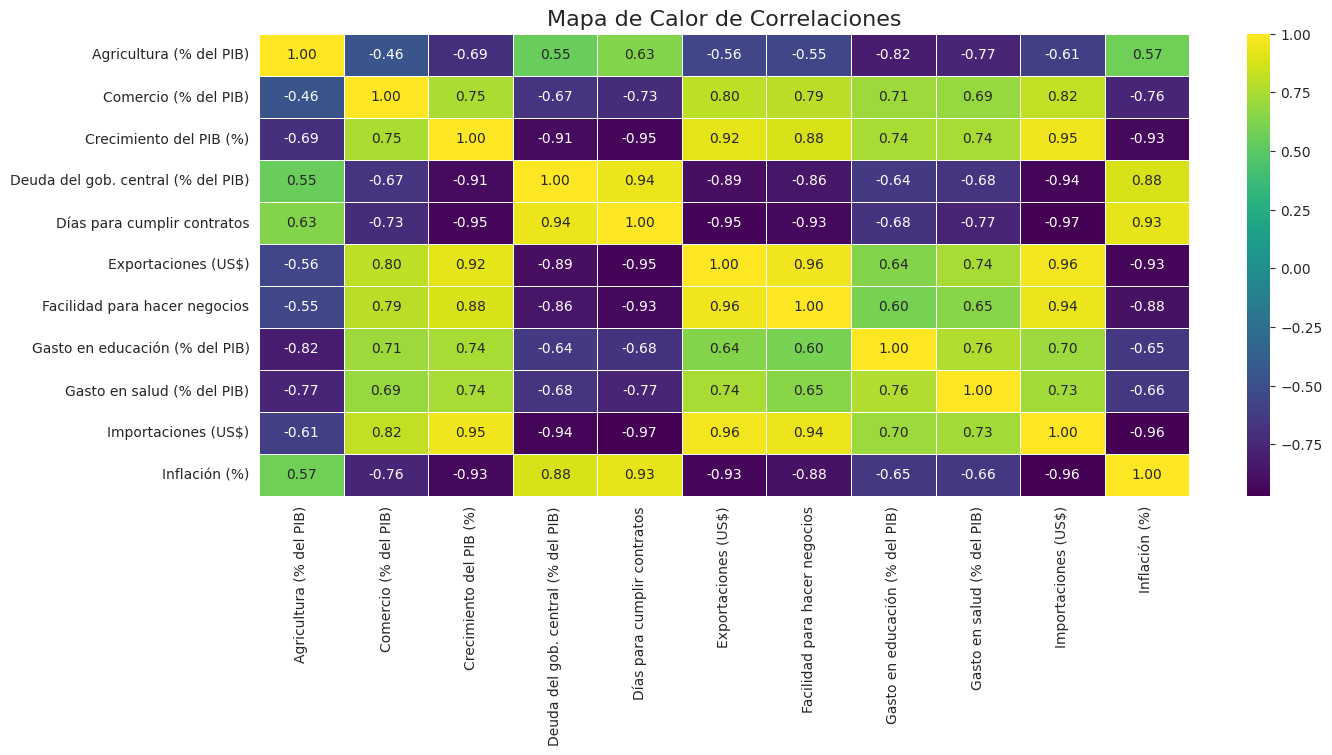

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convertir a numérico
df_numeric = df_final_imputed.apply(pd.to_numeric, errors='coerce')

# Rellenar NaN con la media
df_numeric = df_numeric.fillna(df_numeric.mean())

# Calcular matriz de correlación
corr_matrix = df_numeric.corr()

# Graficar heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=16)
plt.show()


4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

El mapa de calor muestra relaciones importantes entre las variables económicas analizadas para los países de Latinoamérica. Se observa una correlación positiva muy alta entre exportaciones e importaciones (0.96), lo que indica que los países con mayor nivel de comercio exterior tienden a presentar tanto mayores ventas como mayores compras internacionales.

También destaca la relación positiva entre crecimiento del PIB e importaciones (0.95) y entre crecimiento del PIB y exportaciones (0.92), lo que sugiere que un mayor dinamismo económico suele estar acompañado por una mayor actividad comercial internacional.

Por otro lado, existe una fuerte correlación negativa entre días para cumplir contratos e importaciones (-0.97) y entre esta variable y el crecimiento del PIB (-0.95). Esto indica que una menor eficiencia institucional puede afectar negativamente el clima de inversión.

Finalmente, la inflación presenta correlaciones negativas altas con variables como importaciones (-0.96), exportaciones (-0.93) y crecimiento económico (-0.93), lo que sugiere que mayores niveles de inflación suelen asociarse con entornos macroeconómicos menos favorables para la inversión y el crecimiento.

4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_final_imputed.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(14, 11)


### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_scaled)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

print(varianza_acumulada)

[0.80432386 0.89486154 0.93597174 0.95991133 0.97641891 0.9864744
 0.99249496 0.99665217 0.99895635 0.99961687 1.        ]


5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

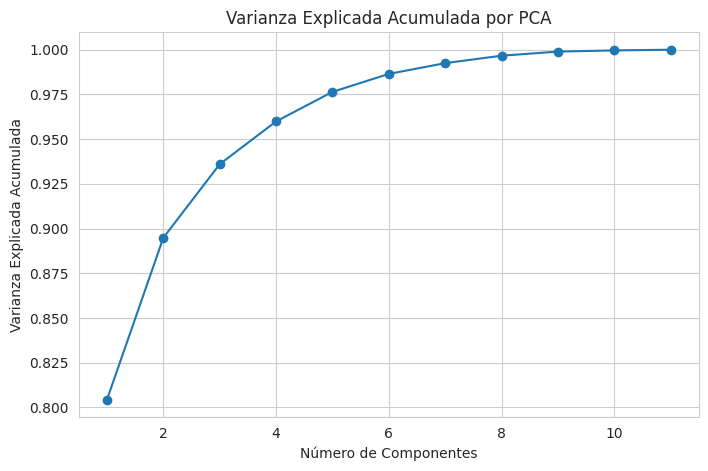

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker='o'
)

plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Varianza Explicada Acumulada por PCA")
plt.grid(True)

plt.show()

5.3. Realiza un análisis del gráfico anterior.

El gráfico de varianza explicada acumulada muestra que el primer componente principal explica aproximadamente el 80.4% de la varianza total, lo cual representa una proporción muy alta de la información contenida en las once variables originales.

Al incorporar el segundo componente, la varianza acumulada aumenta hasta cerca del 89.5%, y con tres componentes supera el 93%. Sin embargo, a partir del primer componente el incremento marginal comienza a reducirse de forma importante, lo que indica rendimientos decrecientes en términos de información adicional capturada.

Esto sugiere que una gran parte de la estructura económica de los datos puede resumirse en una sola dimensión principal. Desde una perspectiva práctica, esto permite construir un índice sintético del clima de inversión sin perder demasiada información relevante, facilitando la comparación entre países y simplificando el análisis.

### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [ ]:
pca_final = PCA(n_components=1)

X_pca = pca_final.fit_transform(X_scaled)

print(X_pca.shape)
print(pca_final.explained_variance_ratio_)

(14, 1)
[0.80432386]


6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

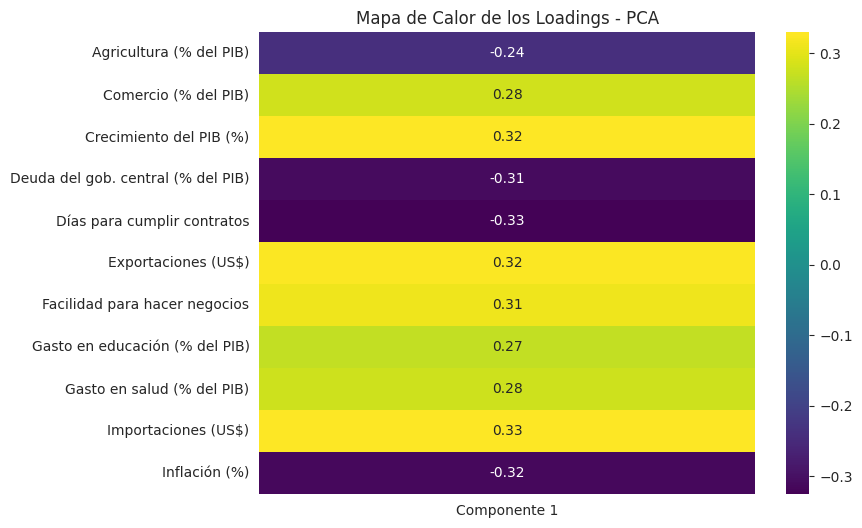

In [ ]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=X.columns,
    columns=['Componente 1']
)

plt.figure(figsize=(8,6))
sns.heatmap(loadings, annot=True, cmap='viridis', center=0)

plt.title("Mapa de Calor de los Loadings - PCA")
plt.show()

6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

El mapa de calor de los loadings muestra que el primer componente principal está fuertemente influenciado por variables como importaciones (0.33), exportaciones (0.32), crecimiento del PIB (0.32) y facilidad para hacer negocios (0.31), todas con cargas positivas altas. Esto indica que los países con mayores niveles de comercio internacional, mayor dinamismo económico y mejores condiciones institucionales tienden a obtener mejores resultados en este componente.

También presentan cargas positivas relevantes variables como comercio (% del PIB), gasto en educación y gasto en salud, lo que refuerza la idea de que economías más abiertas, con mayor inversión social y mejor entorno empresarial, generan un clima más favorable para la inversión extranjera.

Por el contrario, variables como días para cumplir contratos (-0.33), inflación (-0.32) y deuda del gobierno central (-0.31) presentan cargas negativas altas. Esto significa que mayores niveles de inflación, mayor endeudamiento público y procesos institucionales más lentos afectan negativamente el atractivo de un país para recibir inversión.

### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [ ]:
df_final['Indice_Inversion'] = X_pca[:, 0]
df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
Panamá,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.89
Costa Rica,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.75
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.13
Perú,8.14,55.06,4.78,59.39,677.46,"70,328,751,109.66",4.25,5.24,6.10,NaN,16.79,0.66


7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [ ]:
df_final = df_final.sort_values(
    by='Indice_Inversion',
    ascending=False
)

df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
Panamá,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.89
Costa Rica,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.75
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.13
Uruguay,8.21,64.01,4.47,NaN,717.08,"63,598,148,937.21",NaN,5.63,6.65,"59,086,857,093.80",11.66,1.09


7.2. Convierte 'ShortName' en una columna del dataframe.

In [ ]:
df_final = df_final.reset_index()

df_final.head()

,ShortName,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
0,Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.89
1,Panamá,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.89
2,Costa Rica,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.75
3,Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.13
4,Uruguay,8.21,64.01,4.47,NaN,717.08,"63,598,148,937.21",NaN,5.63,6.65,"59,086,857,093.80",11.66,1.09


7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

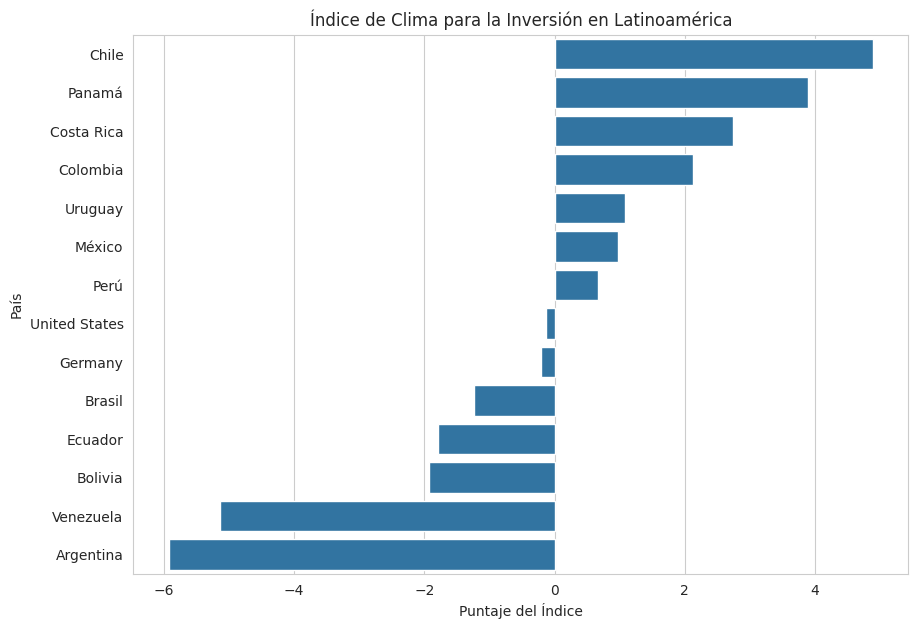

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=df_final,
    x='Indice_Inversion',
    y='ShortName'
)

plt.title("Índice de Clima para la Inversión en Latinoamérica")
plt.xlabel("Puntaje del Índice")
plt.ylabel("País")

plt.show()

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

El gráfico del Índice de Clima para la Inversión muestra diferencias claras entre los países analizados de América Latina. Chile lidera ampliamente el ranking, seguido por Panamá, Costa Rica y posteriormente Colombia, lo que indica que estos países presentan mejores condiciones estructurales para atraer inversión extranjera directa.

Chile se posiciona como el principal competidor regional debido a su alta estabilidad macroeconómica, menores niveles de inflación, mayor apertura comercial y mejores indicadores institucionales. Panamá también destaca por su fuerte integración internacional y facilidad para hacer negocios, mientras que Costa Rica muestra un entorno favorable apoyado en estabilidad y gasto social relativamente sólido.

Colombia aparece en una posición competitiva, pero aún por debajo de estos líderes regionales. Aunque presenta buen crecimiento económico y tamaño de mercado atractivo, sigue enfrentando debilidades en variables como eficiencia institucional, tiempos para cumplir contratos y algunas restricciones en facilidad para hacer negocios, factores que reducen su ventaja frente a otros países.

Países como Argentina y Venezuela aparecen en los últimos lugares del ranking debido a altos niveles de inflación, mayor inestabilidad macroeconómica y menor confianza institucional, lo que deteriora significativamente su clima de inversión.

Para el MinCIT, estos resultados sugieren que los principales competidores en la atracción de capitales extranjeros son Chile, Panamá y Costa Rica. Colombia debe fortalecer su competitividad mejorando la eficiencia regulatoria, reduciendo barreras institucionales y consolidando la estabilidad macroeconómica, ya que estos factores son determinantes para aumentar la confianza de los inversionistas internacionales y posicionarse mejor dentro de la región.